<img src="https://raw.githubusercontent.com/CHoRUS-UF/notebooks/main/graphics/header.png" width="75%"/>

# **Deep Learning for Medical Imaging**
### Part I: Medical Image Classification
---

In this notebook, we use the ResNet50 architecture for image classification. We, first, import the model with all its layers except the last layer, as we modify the last layer as per our need. We need only three neurons in the last layer as our dataset has three classes only. Also, we chose ResNet50 over other deep learning architecture for the following reasons:

1. **Deeper architectures:** ResNet50 is a deeper architecture that can handle more complex tasks than other architectures like VGG16. It achieves this by using skip connections that enable information to flow directly from one layer to another, bypassing the intermediate layers. This enables the network to learn deeper representations and handle more complex tasks.

2. **Faster convergence:** ResNet50 converges faster than other architectures due to the use of skip connections that allow gradients to flow directly through the network. This enables the network to learn faster and converge to a good solution faster.

3. **Better generalization:** ResNet50 has been shown to generalize better than other deep learning architectures. This is attributed to its ability to handle deeper architectures and the use of skip connections that reduce the vanishing gradient problem. This enables the network to learn more robust features that generalize better to unseen data.

<figure>
    <img src="https://raw.githubusercontent.com/CHoRUS-UF/notebooks/main/graphics/resnet.png" />
    <figcaption><center><b>ResNet, a popular convolutional neural network (CNN) architecture for processing image inputs.</b></center></figcaption>
</figure>


### Importing the Necessary Packages
In the following code block, we will import all the required packages to run this notebook.

In [1]:
import numpy as np
import time
import gdown, os, zipfile, shutil
import PIL.Image as Image
import matplotlib.pylab as plt

import tensorflow as tf
from pathlib import Path
import seaborn as sns

try:
  import splitfolders
except:
  !pip install split-folders
  import splitfolders

ModuleNotFoundError: No module named 'gdown'

### Dataset

For demonstrating the use of deep learning for classifying medical images, we will use the [LC25000 LUNG AND COLON HISTOPATHOLOGICAL IMAGE DATASET](https://academictorrents.com/details/7a638ed187a6180fd6e464b3666a6ea0499af4af). This dataset contains histopathological images for different forms of lung cancer.

To remain appropriately high-level, we have already downsampled the images to 256x256x3. Download our preprocessed dataset by clicking [this link](https://drive.google.com/file/d/1GLS8-c68-EY7VkNWRLo4OjiRh4_iN2Nx/view?usp=share_link).

### Getting to know the Dataset

The following lines of codes are used to build intution and compute select statistics of the dataset (e.g., number of images, classes, sizes).

After executing the code block, we can see that there are three classes, and each class has 150 images. Additionally, the size of each image is 256x256x3 pixels.

In [2]:
data_path = Path(os.getcwd()+'/500LungDataset')
sub_dir = [f.path for f in os.scandir(data_path)]
img = plt.imread(sub_dir[0] + '/' + os.listdir(sub_dir[0])[0])

print(f"There are {len(sub_dir)} classes.")
for class_num, class_path in enumerate(sub_dir):
  print(f"Class {class_num} is {os.path.split(class_path)[-1]} and has {len(os.listdir(class_path))} images")
print('The shape of each image is {}'.format(img.shape))

### Three classes, adenocarcinoma(ACA), Squamous cell carcinoma (SCC), and normal

There are 3 classes.
Class 0 is Lung_ACA and has 500 images
Class 1 is Lung_SCC and has 500 images
Class 2 is Lung_Normal and has 500 images
The shape of each image is (256, 256, 3)


### Splitting the Dataset
In the following lines of code, we split our dataset into training, testing, and validation datasets, such that the training dataset contains 80% of the total dataset, validation dataset contains 10% of the total images, and finally, testing dataset contains 10% of dataset.

In [3]:
splitfolders.ratio(data_path, # The location of dataset
                   output=Path(os.getcwd() + '/data_dir'), # The output location
                   seed=502, # The number of seed
                   ratio=(.8, .1, .1), # The ratio of splited dataset
                   group_prefix=None, # If your dataset contains more than one file like ".jpg", ".pdf", etc
                   move=False # If you choose to move, turn this into True
                   )

Copying files: 1500 files [00:00, 2475.81 files/s]


# Data Augmentation

In the following lines of code, we apply data augmentation to the training dataset via horizontal flipping, vertical flipping, and 90 degree rotation. All images are normalized from [0, 255] to range [0, 1].

In [4]:
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1./255.0)
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)

### Creating the Input Pipline
In the following lines of code, we use the `flow_from_directory` class of TensorFlow to make the input pipeline for our training, testing, and validation datasets. Doing so will enable us to apply the augmentation on the go while reading images from the directories and provide us the chunks of images and their corresponding classes (labels) while training.

In [5]:
main_path = os.getcwd() + '/data_dir'

train_dataset = train_datagen.flow_from_directory(
    directory= main_path + '/train/',
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=16,
    class_mode="categorical",
    shuffle=True,
    seed=None)

val_dataset = val_datagen.flow_from_directory(
    directory = main_path + '/val',
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=150,
    class_mode="categorical",
    shuffle=False,
    seed=None)

test_dataset = test_datagen.flow_from_directory(
    directory = main_path + '/test',
    target_size=(224, 224),
    color_mode="rgb",
    batch_size=150,
    class_mode="categorical",
    shuffle=False,
    seed=None)

Found 1278 images belonging to 3 classes.
Found 336 images belonging to 3 classes.
Found 372 images belonging to 3 classes.


### Visualizing the Dataset
In the following lines of code, we do the visualization of some of the images to better understand our dataset visually. The images, along with their labels, are shown below.

Class Names: {'Lung_ACA': 0, 'Lung_Normal': 1, 'Lung_SCC': 2}


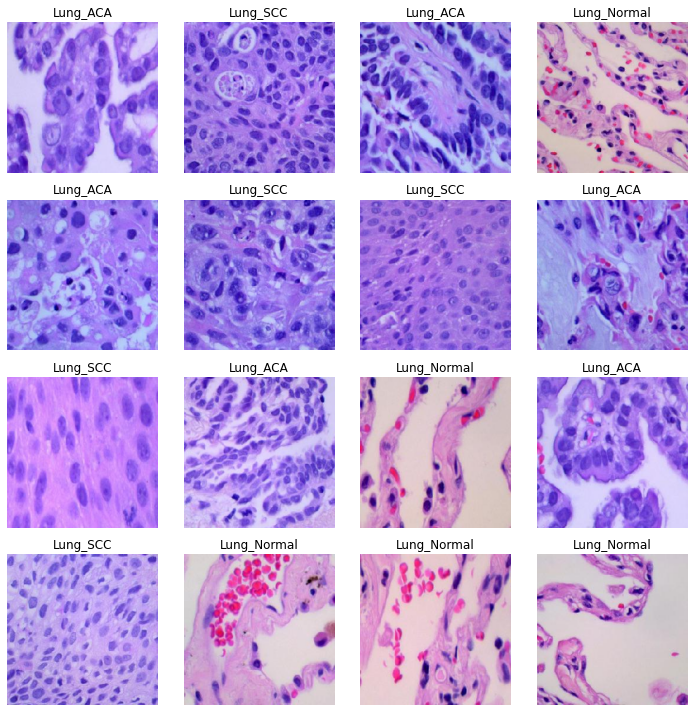

In [6]:
class_names = list(train_dataset.class_indices)
img, lab  = next(train_dataset)
lab = np.argmax(lab, axis = -1)
print('Class Names: {}'.format(train_dataset.class_indices))
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(16):
  plt.subplot(4, 4, i+1)
  plt.imshow(img[i])
  plt.axis("off")
  plt.title(class_names[lab[i]])
  

plt.tight_layout()

When we train our model, the input pipeline will feed batches of 16 images to our model, as shown below. 

In [7]:
for image_batch, labels_batch in train_dataset:
  print('Image Shape: {}'.format(image_batch.shape))
  print('Label Shape: {}'.format(labels_batch.shape))
  break

Image Shape: (16, 224, 224, 3)
Label Shape: (16, 3)


# Downloading the ResNet50 Model Architecture

Let's download the ResNet50 architecture from the TensorFlow hub. The details of the ResNet50 model are as follows:

The ResNet50 architecture is a deep convolutional neural network (CNN) that consists of 50 layers. The architecture was introduced by [He et al.](https://arxiv.org/abs/1512.03385) in 2015 and has since become a popular choice for various computer vision tasks.

Here are the details of the ResNet50 architecture:
- **Input layer:** The input layer takes an image as input and processes it using convolutional filters.
- **Convolutional layers:** The network consists of several convolutional layers that extract features from the input image. The filters in these layers have different sizes and strides, allowing the network to extract features at multiple scales.
- **Residual blocks:** The ResNet50 architecture uses residual blocks to address the vanishing gradient problem that occurs in deep networks. A residual block consists of two or three convolutional layers followed by a skip connection that allows the gradient to flow directly to the next layer.

- **Max pooling layers:** Max pooling layers are used to downsample the feature maps and reduce the spatial dimensions of the feature maps.

- **Fully connected layers:** The fully connected layers at the end of the network process the feature maps and produce the final classification output.

- **Softmax layer:** The softmax layer produces the final classification output by applying the softmax function to the output of the fully connected layers.

In summary, the ResNet50 architecture is a deep CNN that uses residual blocks to address the vanishing gradient problem. The architecture consists of several convolutional layers, max pooling layers, fully connected layers, global average pooling layer, and a softmax layer. The architecture has been shown to achieve high accuracy on various image classification benchmarks.

In [8]:
resnet_50 = tf.keras.applications.resnet50.ResNet50(include_top=False, weights='imagenet')
resnet_50.trainable=False ### freeze all layers
resnet_50.summary()

Metal device set to: Apple M1 Max
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, None, None,   0           ['input_1[0][0]']                
                                3)                                                                
                                                                                                  
 conv1_conv (Conv2D)            (None, None, None,   9472        ['conv1_pad[0][0]']              
                                64)                      

                                                                                                  
 conv2_block2_add (Add)         (None, None, None,   0           ['conv2_block1_out[0][0]',       
                                256)                              'conv2_block2_3_bn[0][0]']      
                                                                                                  
 conv2_block2_out (Activation)  (None, None, None,   0           ['conv2_block2_add[0][0]']       
                                256)                                                              
                                                                                                  
 conv2_block3_1_conv (Conv2D)   (None, None, None,   16448       ['conv2_block2_out[0][0]']       
                                64)                                                               
                                                                                                  
 conv2_blo

                                128)                                                              
                                                                                                  
 conv3_block2_2_bn (BatchNormal  (None, None, None,   512        ['conv3_block2_2_conv[0][0]']    
 ization)                       128)                                                              
                                                                                                  
 conv3_block2_2_relu (Activatio  (None, None, None,   0          ['conv3_block2_2_bn[0][0]']      
 n)                             128)                                                              
                                                                                                  
 conv3_block2_3_conv (Conv2D)   (None, None, None,   66048       ['conv3_block2_2_relu[0][0]']    
                                512)                                                              
          

 conv4_block1_1_bn (BatchNormal  (None, None, None,   1024       ['conv4_block1_1_conv[0][0]']    
 ization)                       256)                                                              
                                                                                                  
 conv4_block1_1_relu (Activatio  (None, None, None,   0          ['conv4_block1_1_bn[0][0]']      
 n)                             256)                                                              
                                                                                                  
 conv4_block1_2_conv (Conv2D)   (None, None, None,   590080      ['conv4_block1_1_relu[0][0]']    
                                256)                                                              
                                                                                                  
 conv4_block1_2_bn (BatchNormal  (None, None, None,   1024       ['conv4_block1_2_conv[0][0]']    
 ization) 

                                                                                                  
 conv4_block3_3_bn (BatchNormal  (None, None, None,   4096       ['conv4_block3_3_conv[0][0]']    
 ization)                       1024)                                                             
                                                                                                  
 conv4_block3_add (Add)         (None, None, None,   0           ['conv4_block2_out[0][0]',       
                                1024)                             'conv4_block3_3_bn[0][0]']      
                                                                                                  
 conv4_block3_out (Activation)  (None, None, None,   0           ['conv4_block3_add[0][0]']       
                                1024)                                                             
                                                                                                  
 conv4_blo

 ization)                       256)                                                              
                                                                                                  
 conv4_block6_2_relu (Activatio  (None, None, None,   0          ['conv4_block6_2_bn[0][0]']      
 n)                             256)                                                              
                                                                                                  
 conv4_block6_3_conv (Conv2D)   (None, None, None,   263168      ['conv4_block6_2_relu[0][0]']    
                                1024)                                                             
                                                                                                  
 conv4_block6_3_bn (BatchNormal  (None, None, None,   4096       ['conv4_block6_3_conv[0][0]']    
 ization)                       1024)                                                             
          

 conv5_block3_1_conv (Conv2D)   (None, None, None,   1049088     ['conv5_block2_out[0][0]']       
                                512)                                                              
                                                                                                  
 conv5_block3_1_bn (BatchNormal  (None, None, None,   2048       ['conv5_block3_1_conv[0][0]']    
 ization)                       512)                                                              
                                                                                                  
 conv5_block3_1_relu (Activatio  (None, None, None,   0          ['conv5_block3_1_bn[0][0]']      
 n)                             512)                                                              
                                                                                                  
 conv5_block3_2_conv (Conv2D)   (None, None, None,   2359808     ['conv5_block3_1_relu[0][0]']    
          

### Modifying the ResNet50 Architecture

In the following lines of code, we modify the architecture of the ResNet50 as per our needs. We do the following addition to the existing model.
1. We flatten (reshape) the output from ResNet50.
2. We add a feedforward layer with only three neurons and the softmax activation function.

In [9]:
inputs = tf.keras.Input(shape=(224,224,3))
x = resnet_50(inputs)
x = tf.keras.layers.Flatten()(x)
outputs = tf.keras.layers.Dense(3, activation="softmax")(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="my_model")
metrics = [tf.keras.metrics.CategoricalAccuracy()]
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0003)
loss = tf.keras.losses.CategoricalCrossentropy()
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, None, None, 2048)  23587712  
                                                                 
 flatten (Flatten)           (None, 100352)            0         
                                                                 
 dense (Dense)               (None, 3)                 301059    
                                                                 
Total params: 23,888,771
Trainable params: 301,059
Non-trainable params: 23,587,712
_________________________________________________________________


# Train the Model

Finally, in the following lines, we train our model.

In [10]:
history = model.fit(train_dataset, validation_data=val_dataset,  epochs=20)

Epoch 1/20


2023-09-07 07:55:43.012157: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


80/80 [==============================] - 10s 101ms/step - loss: 1.2832 - categorical_accuracy: 0.4030 - val_loss: 0.9114 - val_categorical_accuracy: 0.6190
Epoch 2/20
80/80 [==============================] - 8s 97ms/step - loss: 0.9311 - categorical_accuracy: 0.5736 - val_loss: 0.9546 - val_categorical_accuracy: 0.4375
Epoch 3/20
80/80 [==============================] - 7s 91ms/step - loss: 0.9422 - categorical_accuracy: 0.5665 - val_loss: 0.8105 - val_categorical_accuracy: 0.6220
Epoch 4/20
80/80 [==============================] - 7s 93ms/step - loss: 0.7712 - categorical_accuracy: 0.6706 - val_loss: 0.6901 - val_categorical_accuracy: 0.7530
Epoch 5/20
80/80 [==============================] - 8s 95ms/step - loss: 0.8113 - categorical_accuracy: 0.6502 - val_loss: 1.0185 - val_categorical_accuracy: 0.4524
Epoch 6/20
80/80 [==============================] - 8s 95ms/step - loss: 0.7678 - categorical_accuracy: 0.6471 - val_loss: 0.6575 - val_categorical_accuracy: 0.7500
Epoch 7/20
80/80 [=

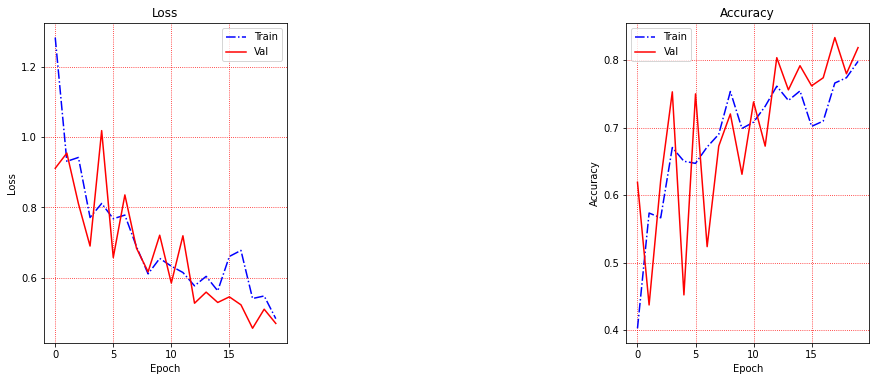

In [11]:
plt.figure(figsize = (20, 20))
plt.subplot(341)
plt.plot(history.history['loss'], color='blue', linestyle = 'dashdot', label='Train')
plt.plot(history.history['val_loss'], color='red', linestyle="solid", label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.grid(visible = True, which = 'both', color= 'r', linestyle = 'dotted')
plt.legend()

plt.subplot(343)
plt.plot(history.history['categorical_accuracy'], color='blue', linestyle = 'dashdot', label='Train')
plt.plot(history.history['val_categorical_accuracy'], color='red', linestyle="solid", label='Val')
# plt.xticks(np.arange(0, 31, step=2))  # Set label locations.
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.grid(visible = True, which = 'both', color= 'r', linestyle = 'dotted')
plt.legend()

# Monitoring Our Model's Loss

Let's plot loss agains all the epochs for training and validation dataset. It can be seen that the performance of our model for both training dataset and validation dataset is extremely good. In addition, more importantly, the difference between validation and training data is extremly small which indicates that our model generalizes better.

# Evaluating Our Model's Performance on the Test Dataset

Let's examine how our model generalizes to the unseen images in the test dataset. We can see that our model's performance is exceptionally good for testing dataset, which subsequently indicates that our model is ready to be used for realtime data.

In [12]:
test_result = model.evaluate(test_dataset, batch_size = 128)

3/3 [==============================] - 2s 454ms/step - loss: 0.4913 - categorical_accuracy: 0.8038


In [13]:
print('Test Loss: {}'.format(test_result[0]))
print('Test Accuracy: {}'.format(test_result[1]))

Test Loss: 0.49126261472702026
Test Accuracy: 0.8037634491920471


# Confusion Matrix

A confusion matrix is a table that is often used to describe the performance of a classification model. It shows the number of correct and incorrect predictions made by the model compared to the actual outcomes (i.e., true positives, true negatives, false positives, and false negatives).

In the case of multiclass classification, the confusion matrix has multiple rows and columns, with each row and column representing a class. The diagonal elements of the matrix represent the number of correctly classified instances for each class, while the off-diagonal elements represent the misclassified instances.

The confusion matrix is useful for several reasons. It provides a more detailed breakdown of the performance of a classification model than simple accuracy metrics, which only measure overall performance. The confusion matrix allows us to analyze the types of errors the model is making and identify which classes are more difficult to predict.

Based on the confusion matrix, we can compute several performance metrics such as precision, recall, and F1-score for each class. These metrics provide additional insights into the performance of the model and can be used to compare the performance of different models or to optimize hyperparameters.

Overall, the confusion matrix is a powerful tool for evaluating the performance of a multiclass classification model and identifying areas for improvement.

The following lines are used to create the confusion matrix for the testing dataset.

3/3 [==============================] - 2s 503ms/step


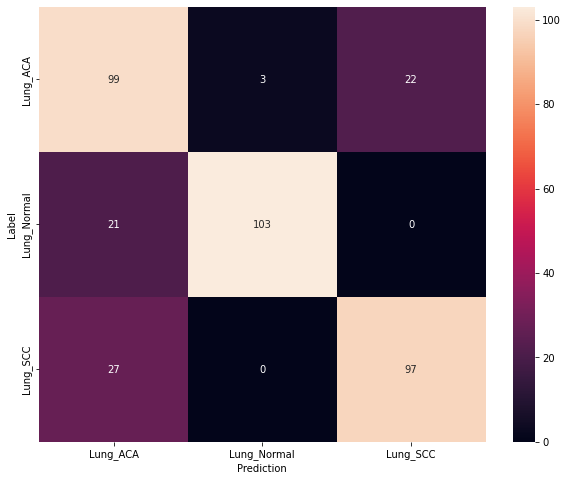

In [14]:
label_names = class_names
y_pred = model.predict(test_dataset, batch_size=64)
y_test = test_dataset.labels
cm = tf.math.confusion_matrix(y_test, 
                              y_pred.argmax(axis=1),
                              num_classes = 3)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, 
              annot=True, fmt='g')
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.savefig('CM.png', dpi = 300)
plt.show()

---
> 🔗 This module is based on course material from Wei Shao, EEL6935 Deep Learning in Medical Image Analysis, Department of Electrical and Computer Engineering, University of Florida.
---